In [1]:
%run ../../../../Script/analysisLibraries

In [2]:
%matplotlib inline

In [3]:
%load_ext rpy2.ipython

Read data and make SDA tables. Either read the separate datasets and concatenate them, or read the data concatenated as a whole.

In [4]:
adata = sc.read('../write/adata.dpt.h5ad')

In [5]:
adata.layers.keys()

KeysView(Layers with keys: SCT_counts, correct_counts, raw_counts, scaled_counts, spliced, unspliced)

In [6]:
adata.X = adata.layers['scaled_counts'].copy()

Here we choose HVGs where variance is above the middle peak of the two variance distributions for cells and nuclei

<Axes: xlabel='variance-Cells', ylabel='Count'>

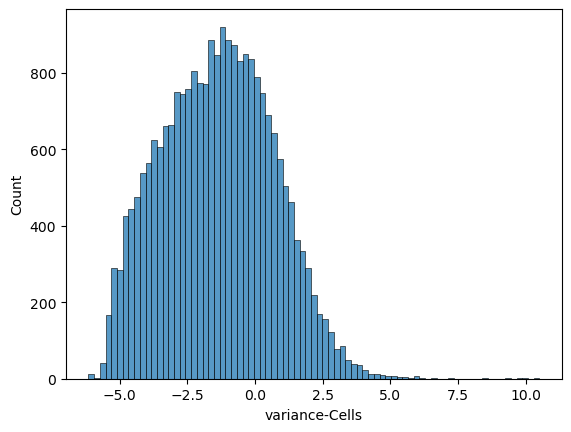

In [7]:
sns.histplot( np.log(adata.var['variance-Cells']))

<Axes: xlabel='variance-Nuclei', ylabel='Count'>

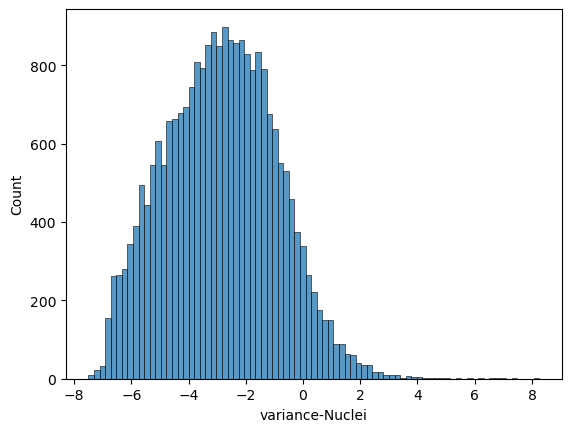

In [8]:
sns.histplot( np.log(adata.var['variance-Nuclei']))

In [9]:
sum( (np.log(adata.var['variance-Cells'])>0)|(np.log(adata.var['variance-Nuclei']>-1)) )

6276

In [10]:
var_genes = (np.log(adata.var['variance-Cells'])>0)|(np.log(adata.var['variance-Nuclei']>-1))

In [11]:
df = pd.DataFrame(adata[:,var_genes].X, 
                        index=adata.obs_names,
                        columns=adata[:,var_genes].var_names)

export data and cells barcodes

In [12]:
df.shape

(10547, 6276)

In [33]:
df.to_csv('./ALLDATA_scaled_onematrix_data.csv' ,
            index=False, header=False, sep=' ')

Now you need to run the script for sda `sdaWorkflow.py` with `gwf`. You need to write by hand the number of cells in the script. It is highlighted by a comment.

In [22]:
#!gwf -b slurm -f sdaWorkflow.py run ALLDATA_scaled_onematrix_data

You are currently running version 1.7.1, but the latest version is 1.7.2. Consider updating. You can disable this check with `gwf config set check_updates no`.


Analysis Example on one component

In [5]:
#adata = ad.AnnData.concatenate(CELL, NUCLEI)

In [13]:
A = pd.read_csv('./ALLDATA_scaled_onematrix_data_100comps/it2000/A', sep=' ', header=None)
#B is only for multi-tissues tensor
#B = pd.read_csv('SDA/ALLDATA_scaled_onematrix_data/it2000/B1', sep=' ', header=None)
X = pd.read_csv('./ALLDATA_scaled_onematrix_data_100comps/it2000/X1', sep=' ', header=None)

$A$ contains the score of each cell in the components. This score can be used as a "soft clustering" once it is normalized. We will try to do that in the notebook that follows this one. 

In [14]:
A.shape

(10548, 100)

In [15]:
A.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.237044,-0.444741,-0.521709,-0.421176,-0.191632,-0.039443,-0.011519,0.313026,-0.017442,-0.014353,...,-0.713952,0.084345,0.325848,0.577062,-0.704971,-0.307896,0.102466,-0.919935,-0.196817,-1.101270
1,0.411126,-0.113899,-0.404359,-0.412903,0.112982,-0.168036,-0.364643,0.746365,-0.003497,-0.242012,...,0.923655,-0.432896,0.018581,-0.329805,-0.004898,-0.298961,0.290554,0.328762,-0.211422,0.605521
2,-0.554124,-2.115210,0.572701,-0.509780,0.577237,-0.234850,0.450509,0.208679,0.177719,-0.164977,...,-0.382789,0.511820,0.686443,0.116738,-0.315359,-0.109686,1.740900,-0.937221,0.846761,0.562644
3,-0.258430,1.402740,1.303190,-0.759115,1.298820,-0.058847,-0.725280,-0.359907,0.306425,1.195000,...,-0.727815,0.416148,2.020470,-0.108066,-0.465147,-1.716540,0.712520,-0.855888,0.907461,0.266163
4,-0.338097,1.336100,-1.538940,0.907896,0.817900,1.415150,-0.130066,-0.545487,-0.755909,-0.912024,...,-1.259190,-0.325736,0.157799,1.454890,-0.115039,-0.391225,1.149520,0.961979,-0.198099,0.624347


$X$ contains the loading of each gene in each component according to the spike-and-slab prior. The sign of the loading has to be considered together with the sign of the cell score to see if the resulting sign is positive (significant expression of gene) or negative (significant underexpression of gene)

In [16]:
X.columns = df.columns

In [17]:
X.shape

(100, 6276)

In [18]:
X.head()

,AURKAIP1,MRPL20,SSU72,LOC469457,GNB1,MORN1,RER1,MMEL1,ACTRT2,CCDC27,...,amplicon-chrX-FAM9A/B/C-6,amplicon-chrX-GAGE10-0,amplicon-chrX-LOC107966365-0,amplicon-chrX-LOC112206844-0,amplicon-chrX-LOC112206844-2,amplicon-chrX-LOC112206844-4,amplicon-chrX-LOC465705-2,amplicon-chrX-PAGE5-3,amplicon-chrX-SPANXN5-2,amplicon-chrX-SSX1/3/2B-15
0,-0.251518,-0.050381,-0.000772,-0.082587,-0.000094,-0.001789,-0.132522,0.000048,-0.053861,-0.035661,...,0.000333,0.000363,-0.000149,-0.036358,-0.000366,0.002521,-0.061503,0.000056,0.000141,0.006134
1,0.000395,0.000193,-0.000607,0.001750,0.000787,-0.001956,-0.000217,-0.000121,0.000535,-0.000017,...,0.066423,-0.000271,0.000069,0.029602,0.001012,0.000030,-0.000178,0.000639,-0.026457,0.000855
2,-0.000250,-0.000108,-0.000195,0.030246,0.000202,-0.001048,-0.000112,0.000151,-0.001854,-0.000145,...,-0.000141,0.001418,-0.000997,-0.000141,-0.039148,-0.000122,0.000968,-0.000012,-0.001109,0.000334
3,0.000423,-0.000399,-0.000322,0.002582,0.000288,0.000177,-0.000765,0.046786,0.000218,0.000263,...,-0.000404,0.000993,0.000137,0.000224,0.043691,-0.000044,0.000219,0.000187,0.000062,-0.000340
4,-0.000056,-0.000013,0.000059,-0.000223,0.033124,-0.000006,0.000276,-0.107145,0.000001,-0.051293,...,-0.034791,0.000032,0.061013,-0.000074,-0.000050,0.000003,0.000006,0.000007,-0.000034,-0.037562


## Calculate already some stuff to save it in the annotated data object

All components' cell scores 

In [19]:
for i in range(X.shape[0]):
    adata.obs['SDA_cellscore_C'+str(i)] = np.asarray(A.iloc[:,i])

ValueError: Length of values (10548) does not match length of index (10547)

All components' significant cells. I chose threshold based on different runs of SDA and looking at how scores looked like in plots. For each component a cell will be irrelevant, negative or positive based on score thresholds.

In [20]:
A.index = adata.obs_names

for i in range(X.shape[0]):
    score_neg = [-1.5 if i=='Nuclei' else -2 for i in adata.obs['batch']]
    score_pos = [1.5 if i=='Nuclei' else 2 for i in adata.obs['batch']]
    cells_pos = A[i][ A[i]>score_pos ].index
    cells_neg = A[i][ A[i]<score_neg ].index
    adata.obs['sda_cell_relevant_C'+str(i)] = pd.Categorical(
        ['POSITIVE' if i in cells_pos 
         else 'NEGATIVE' if i in cells_neg
         else 'IRRELEVANT'
         for i in adata.obs_names])

ValueError: Length mismatch: Expected axis has 10548 elements, new values have 10547 elements

In [35]:
A.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
AAACCCAAGGACAGCT-Nuclei,0.237044,-0.444741,-0.521709,-0.421176,-0.191632,-0.039443,-0.011519,0.313026,-0.017442,-0.014353,...,-0.713952,0.084345,0.325848,0.577062,-0.704971,-0.307896,0.102466,-0.919935,-0.196817,-1.101270
AAACCCACAGATCCTA-Nuclei,0.411126,-0.113899,-0.404359,-0.412903,0.112982,-0.168036,-0.364643,0.746365,-0.003497,-0.242012,...,0.923655,-0.432896,0.018581,-0.329805,-0.004898,-0.298961,0.290554,0.328762,-0.211422,0.605521
AAACCCAGTTAGTCGT-Nuclei,-0.554124,-2.115210,0.572701,-0.509780,0.577237,-0.234850,0.450509,0.208679,0.177719,-0.164977,...,-0.382789,0.511820,0.686443,0.116738,-0.315359,-0.109686,1.740900,-0.937221,0.846761,0.562644
AAACGAAAGAGCATAT-Nuclei,-0.258430,1.402740,1.303190,-0.759115,1.298820,-0.058847,-0.725280,-0.359907,0.306425,1.195000,...,-0.727815,0.416148,2.020470,-0.108066,-0.465147,-1.716540,0.712520,-0.855888,0.907461,0.266163
AAACGAAAGCTATCCA-Nuclei,-0.338097,1.336100,-1.538940,0.907896,0.817900,1.415150,-0.130066,-0.545487,-0.755909,-0.912024,...,-1.259190,-0.325736,0.157799,1.454890,-0.115039,-0.391225,1.149520,0.961979,-0.198099,0.624347


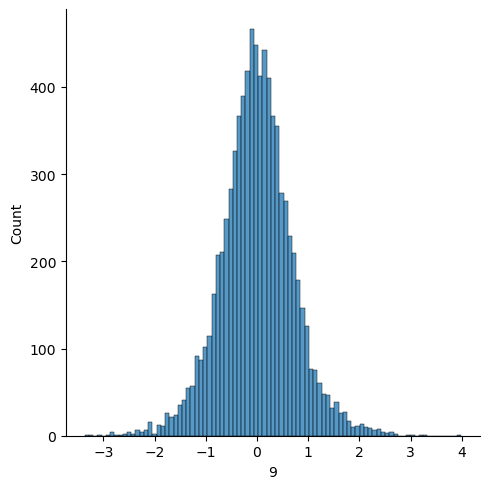

In [40]:
sns.displot(A.loc[adata.obs['batch']=='Nuclei',9])

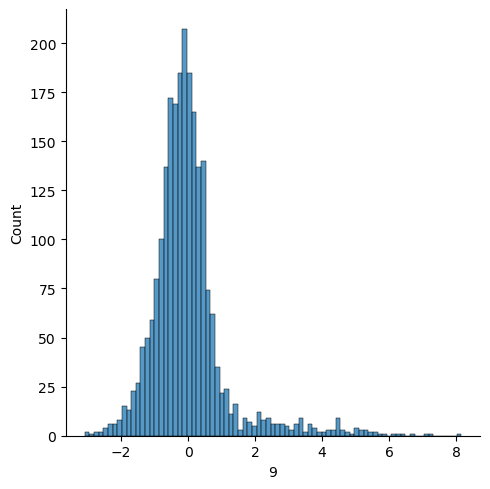

In [41]:
sns.displot(A.loc[adata.obs['batch']=='Cells',9])

All components' significant genes. Significant genes for positive and negative components are saved with a boolean vector in the .var storage of the adata object. Relevant genes are saved with a relaxed and strict threshold (high and low in the name). 

In [47]:
for i in range(X.shape[0]):
    scores = pd.Series( X.T.iloc[:,i], index=adata.var_names )
    #neg_score = np.quantile(scores, .01)
    #pos_score = np.quantile(scores, .9)
    neg_score = -.01
    pos_score = +.01
    component_pos = X.T[i][ X.T[i]>pos_score].index
    component_neg = X.T[i][ X.T[i]<neg_score].index
    adata.var['sda_pos_C'+str(i)] = [i in component_pos for i in adata.var_names]
    adata.var['sda_neg_C'+str(i)] = [i in component_neg for i in adata.var_names]

In [48]:
!mkdir -p write
adata.write('./write/SDA_object_100comps.h5ad')